In this notebook, we will generate some fake data and use it to illustrate some basic ideas about overfitting and cross validation.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

First, let's make some fake data.

**Exercise** Form small groups and make sure that you have a working Jupyter notebook. Generate and make a scatter plot of `x_data` and `y_data`, which are related according to the equation $y = \sin(x)$ with some added noise, where $0 \leq x \leq 2\pi$. The functions `np.random.rand()` and/or `np.random.randn()` may be useful. Choose some reasonable parameters `(n, noise_amp)` for the number of data points and noise amplitude.

In [8]:
n = 50

np.random.rand(n)

array([0.25833537, 0.31427526, 0.66806962, 0.47932461, 0.01460566,
       0.81747864, 0.36502471, 0.38990168, 0.56984333, 0.35747378,
       0.31915447, 0.88615869, 0.90968811, 0.57175871, 0.20316985,
       0.74585481, 0.60618252, 0.6710725 , 0.55210965, 0.04630562,
       0.3953468 , 0.24911725, 0.38906514, 0.58037777, 0.20599119,
       0.02780326, 0.13600713, 0.62952742, 0.0339207 , 0.00695494,
       0.67750923, 0.9072066 , 0.19976102, 0.15074913, 0.72872929,
       0.04853813, 0.84426661, 0.33860926, 0.54603734, 0.91435115,
       0.95774233, 0.37331847, 0.17830771, 0.400478  , 0.81381371,
       0.58959257, 0.53979572, 0.23923601, 0.20017441, 0.41185585])

[4.21822744 1.7621725  4.22073298 1.22845813 2.3314645  0.68678617
 4.78541453 1.01131865 4.85807303 4.56985701 4.65834522 4.01687843
 5.96558279 5.37268484 5.93776188 1.06678958 0.19762247 6.23178639
 5.83185098 5.36367669]


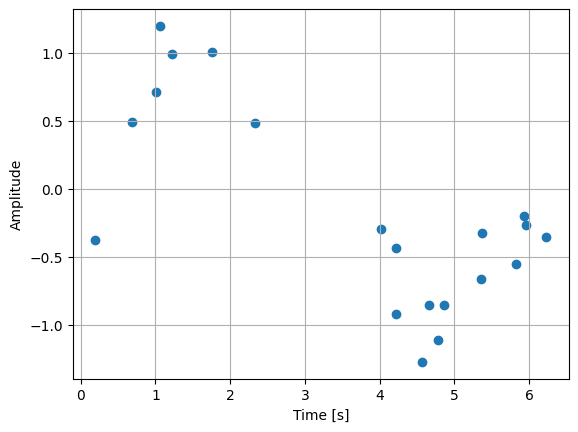

In [23]:
## Solution ##
n = 20
noise_amp = 0.3

noise = noise_amp * np.random.randn(n) # noise is normally distributed
x_data = 2 * np.pi * np.random.rand(n) # random x values between 0 and 2pi
print(x_data)
y_data = np.sin(x_data) + noise

plt.scatter(x_data, y_data)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid()
plt.show()


## A linear fit

We'll use a built-in function to fit the data. Soon we will learn how to do this ourselves from scratch.

In [29]:
np.polyfit?

Signature:       np.polyfit(x, y, deg, rcond=None, full=False, w=None, cov=False)
Call signature:  np.polyfit(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function polyfit at 0x118057c10>
File:            /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/polynomial.py
Docstring:      
Least squares polynomial fit.

.. note::
   This forms part of the old polynomial API. Since version 1.4, the
   new polynomial API defined in `numpy.polynomial` is preferred.
   A summary of the differences can be found in the
   :doc:`transition guide </reference/routines.polynomials>`.

Fit a polynomial ``p(x) = p[0] * x**deg + ... + p[deg]`` of degree `deg`
to points `(x, y)`. Returns a vector of coefficients `p` that minimises
the squared error in the order `deg`, `deg-1`, ... `0`.

The `Polynomial.fit <numpy.polynomial.polynomial.Polynomial.fit>` class
method is recommended for new code as it is more stable numerically. See
the 

In [31]:
# A linear fit.

fit = np.polyfit(x_data, y_data,1)  # read the documentation
beta1, beta0 = fit
print('slope: ', beta1)
print('intercept: ', beta0)

slope:  -0.25287176945825046
intercept:  0.7595660600707418


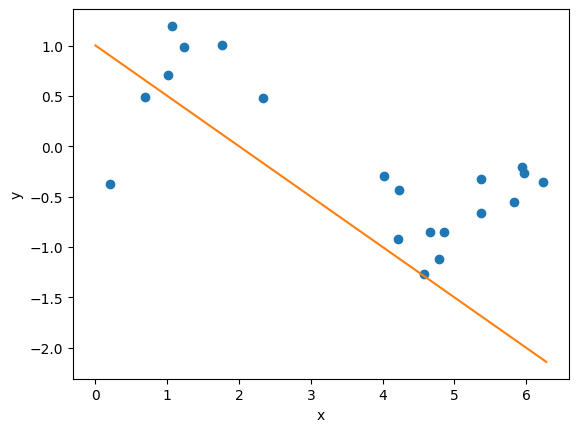

In [38]:
# Plot the data together with the fit.

x_pts = np.arange(0,2*np.pi,0.01)
y_fit = beta0 + beta1 * x_pts
# print(x_pts)
plt.plot(x_data, y_data, 'o')
plt.xlabel('x')
plt.ylabel('y')
plt.plot(x_pts, y_fit)

## A polynomial fit

In [36]:
# A polynomial fit.

fit = np.polyfit(x_data, y_data, 2)
beta2, beta1, beta0 = fit
print(fit)


[ 0.03818779 -0.50079488  1.00319699]


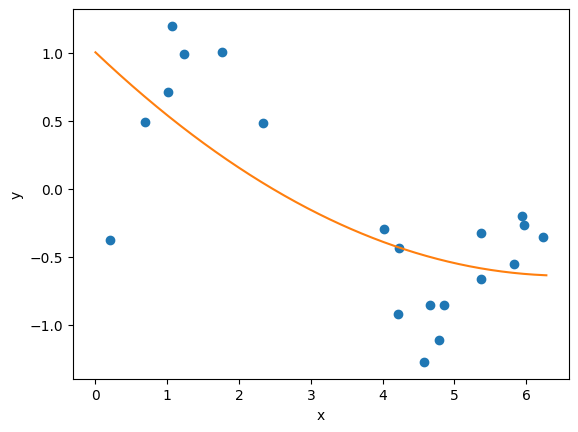

In [56]:
# Plot the data together with the fit.

x_pts = np.arange(0,2*np.pi,0.01)
y_fit = beta0 + beta1*x_pts + beta2*x_pts**2

plt.plot(x_data, y_data, 'o')
plt.xlabel('x')
plt.ylabel('y')
plt.plot(x_pts, y_fit)

# A higher-order polynomial fit

In [54]:
# A polynomial fit.

p = 12
fit = np.polyfit(x_data, y_data, p)
beta_list = fit[::-1]  # flip the list so that it starts with beta0
print(beta_list)


[-1.58040920e+00  1.09250009e+01 -3.66636764e+01  7.90910449e+01
 -1.04709785e+02  9.01968182e+01 -5.25771657e+01  2.09880071e+01
 -5.70237725e+00  1.03104351e+00 -1.18258745e-01  7.76578756e-03
 -2.21998642e-04]


**Exercise:** Write a function `yhat(x, beta_list)` that, given an `x` value and a list of polynomial coefficients, returns the y value of the fitting function.

In [60]:
## Solution ##
def yhat(x, beta_list):
    deg = len(beta_list) # polynomial degree
    y = 0
    for i in range(deg):
        y += beta_list[i] * x**i
    return y
yhat(x_pts, beta_list)

array([-1.5804092 , -1.4747475 , -1.37595839, -1.28360368, -1.19726825,
       -1.11655902, -1.04110401, -0.97055142, -0.90456875, -0.84284189,
       -0.78507437, -0.7309865 , -0.68031465, -0.63281047, -0.58824019,
       -0.54638396, -0.50703517, -0.46999981, -0.43509587, -0.40215277,
       -0.37101076, -0.34152041, -0.31354207, -0.28694541, -0.26160889,
       -0.23741934, -0.21427148, -0.19206755, -0.17071688, -0.1501355 ,
       -0.13024577, -0.11097603, -0.09226026, -0.07403777, -0.05625287,
       -0.03885458, -0.02179634, -0.00503579,  0.01146557,  0.02774254,
        0.04382653,  0.05974571,  0.07552527,  0.09118761,  0.10675252,
        0.12223735,  0.13765723,  0.15302518,  0.16835228,  0.18364784,
        0.1989195 ,  0.21417339,  0.22941425,  0.24464552,  0.25986949,
        0.27508737,  0.2902994 ,  0.30550493,  0.32070255,  0.3358901 ,
        0.35106481,  0.36622333,  0.3813618 ,  0.39647595,  0.41156109,
        0.42661222,  0.44162407,  0.45659112,  0.47150765,  0.48

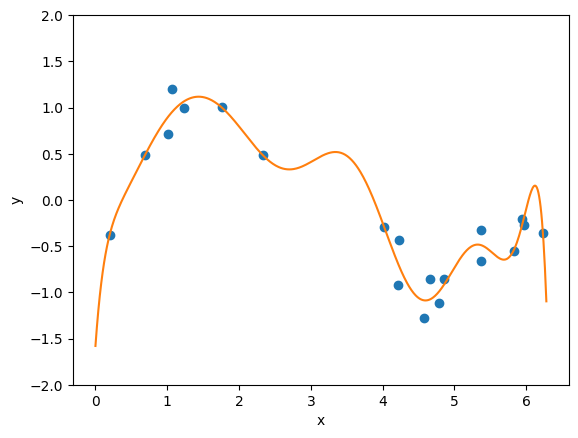

In [59]:
# Plot the data together with the fit.

x_pts = np.arange(0,2*np.pi,0.01)
y_fit = yhat(x_pts, beta_list)

plt.plot(x_data, y_data, 'o')
plt.xlabel('x')
plt.ylabel('y')
plt.plot(x_pts, y_fit)
plt.ylim(-2,2);

# Testing the fit with new data

The above result looks like a very good fit! However, it won't do so well if we apply it to new data that wasn't used to fit the model.

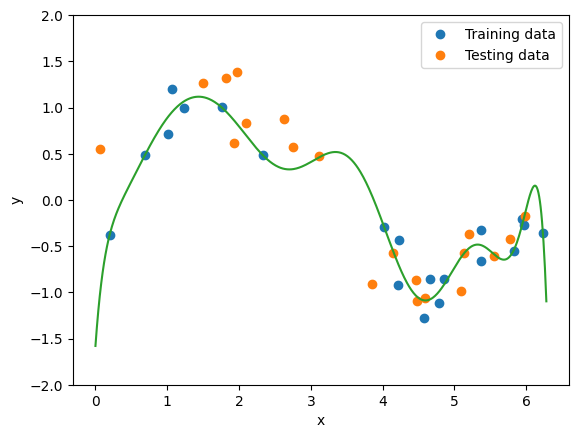

In [58]:
# Make some new simulated data, generated just like the data above:
x_new = 2*np.pi*np.random.rand(n)
noise_amp = 0.3
noise = noise_amp*np.random.randn(n)
y_new = np.sin(x_new) + noise

# Reproduce the last plot, now also plotting the new data:
x_pts = np.arange(0,2*np.pi,0.01)
y_fit = yhat(x_pts, beta_list)

plt.plot(x_data, y_data, 'o')
plt.plot(x_new, y_new, 'o')
plt.xlabel('x')
plt.ylabel('y')
plt.plot(x_pts, y_fit)
plt.legend(['Training data', 'Testing data'])
plt.ylim(-2,2);

It looks like the curve fits the training data well but fits the testing data poorly. In the homework, we'll quantify this difference and use it to select a good model.